In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.6 MB/s eta 0:00:00


In [4]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [7]:
!cp "/content/drive/MyDrive/MedSearch-RL/brain_yolo.zip" .
!unzip -q brain_yolo.zip

replace brain_yolo/images/train/mri_0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [12]:
!cp "/content/drive/MyDrive/MedSearch-RL/brain_dataset.yaml" .

In [14]:
!find brain_yolo | head -50

brain_yolo
brain_yolo/images
brain_yolo/images/val
brain_yolo/images/val/mri_57.jpg
brain_yolo/images/val/mri_582.jpg
brain_yolo/images/val/mri_170.jpg
brain_yolo/images/val/mri_350.jpg
brain_yolo/images/val/mri_109.jpg
brain_yolo/images/val/mri_158.jpg
brain_yolo/images/val/mri_466.jpg
brain_yolo/images/val/mri_543.jpg
brain_yolo/images/val/mri_141.jpg
brain_yolo/images/val/mri_457.jpg
brain_yolo/images/val/mri_185.jpg
brain_yolo/images/val/mri_15.jpg
brain_yolo/images/val/mri_76.jpg
brain_yolo/images/val/mri_221.jpg
brain_yolo/images/val/mri_145.jpg
brain_yolo/images/val/mri_437.jpg
brain_yolo/images/val/mri_443.jpg
brain_yolo/images/val/mri_147.jpg
brain_yolo/images/val/mri_340.jpg
brain_yolo/images/val/mri_127.jpg
brain_yolo/images/val/mri_22.jpg
brain_yolo/images/val/mri_23.jpg
brain_yolo/images/val/mri_131.jpg
brain_yolo/images/val/mri_605.jpg
brain_yolo/images/val/mri_30.jpg
brain_yolo/images/val/mri_73.jpg
brain_yolo/images/val/mri_452.jpg
brain_yolo/images/val/mri_294.jpg
brai

In [22]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="brain_dataset.yaml",
    epochs=50,
    imgsz=512,
    batch=16,
    project="runs",
    name="brain"
)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=brain_dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=brain-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspect

In [16]:
!find /content/brain_yolo | head -20

/content/brain_yolo
/content/brain_yolo/images
/content/brain_yolo/images/val
/content/brain_yolo/images/val/mri_57.jpg
/content/brain_yolo/images/val/mri_582.jpg
/content/brain_yolo/images/val/mri_170.jpg
/content/brain_yolo/images/val/mri_350.jpg
/content/brain_yolo/images/val/mri_109.jpg
/content/brain_yolo/images/val/mri_158.jpg
/content/brain_yolo/images/val/mri_466.jpg
/content/brain_yolo/images/val/mri_543.jpg
/content/brain_yolo/images/val/mri_141.jpg
/content/brain_yolo/images/val/mri_457.jpg
/content/brain_yolo/images/val/mri_185.jpg
/content/brain_yolo/images/val/mri_15.jpg
/content/brain_yolo/images/val/mri_76.jpg
/content/brain_yolo/images/val/mri_221.jpg
/content/brain_yolo/images/val/mri_145.jpg
/content/brain_yolo/images/val/mri_437.jpg
/content/brain_yolo/images/val/mri_443.jpg


In [20]:
with open("/content/drive/MyDrive/MedSearch-RL/brain_dataset.yaml", "w") as f:
    f.write(
"""path: /content/brain_yolo

train: images/train
val: images/val

names:
  0: meningioma
  1: glioma
  2: pituitary
"""
)

In [21]:
!cat brain_dataset.yaml


path: /content/brain_yolo

train: images/train
val: images/val

names:
  0: meningioma
  1: glioma
  2: pituitary


In [25]:
!cp "/content/runs/detect/runs/brain-2/weights/best.pt" \
"/content/drive/MyDrive/MedSearch-RL/"

In [29]:
model = YOLO("/content/runs/detect/runs/brain-2/weights/best.pt")

metrics = model.val()

print("mAP50 =", metrics.box.map50)
print("mAP50-95 =", metrics.box.map)
print("Precision =", metrics.box.mp)
print("Recall =", metrics.box.mr)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2122.5±540.1 MB/s, size: 51.2 KB)
val: Scanning /content/brain_yolo/labels/val.cache... 613 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 613/613 233.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 5.6it/s 6.9s
                   all        613        613      0.907      0.903      0.943      0.661
            meningioma        158        158      0.967      0.968      0.993      0.794
                glioma        271        271      0.857      0.815      0.885      0.543
             pituitary        184        184      0.898      0.924      0.951      0.645
Speed: 1.6ms preprocess, 2.9ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val-3
mAP50 = 0.

In [27]:
results = model.predict(
    source="brain_yolo/images/val",
    save=True,
    conf=0.25
)


image 1/613 /content/brain_yolo/images/val/mri_0.jpg: 512x512 1 glioma, 6.0ms
image 2/613 /content/brain_yolo/images/val/mri_1.jpg: 512x512 1 meningioma, 6.5ms
image 3/613 /content/brain_yolo/images/val/mri_10.jpg: 512x512 1 glioma, 5.9ms
image 4/613 /content/brain_yolo/images/val/mri_100.jpg: 512x512 1 glioma, 5.9ms
image 5/613 /content/brain_yolo/images/val/mri_101.jpg: 512x512 1 meningioma, 5.8ms
image 6/613 /content/brain_yolo/images/val/mri_102.jpg: 512x512 1 meningioma, 5.7ms
image 7/613 /content/brain_yolo/images/val/mri_103.jpg: 512x512 1 pituitary, 5.7ms
image 8/613 /content/brain_yolo/images/val/mri_104.jpg: 512x512 1 glioma, 5.8ms
image 9/613 /content/brain_yolo/images/val/mri_105.jpg: 512x512 1 pituitary, 6.0ms
image 10/613 /content/brain_yolo/images/val/mri_106.jpg: 512x512 1 pituitary, 5.7ms
image 11/613 /content/brain_yolo/images/val/mri_107.jpg: 512x512 1 pituitary, 5.8ms
image 12/613 /content/brain_yolo/images/val/mri_108.jpg: 512x512 1 pituitary, 5.8ms
image 13/613 /

In [24]:
!find /content -name best.pt

/content/runs/detect/runs/brain-2/weights/best.pt


In [30]:
import os

files = os.listdir("/content/runs/detect/predict")
print(files[:10])

['mri_57.jpg', 'mri_582.jpg', 'mri_170.jpg', 'mri_350.jpg', 'mri_109.jpg', 'mri_158.jpg', 'mri_466.jpg', 'mri_543.jpg', 'mri_141.jpg', 'mri_457.jpg']


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

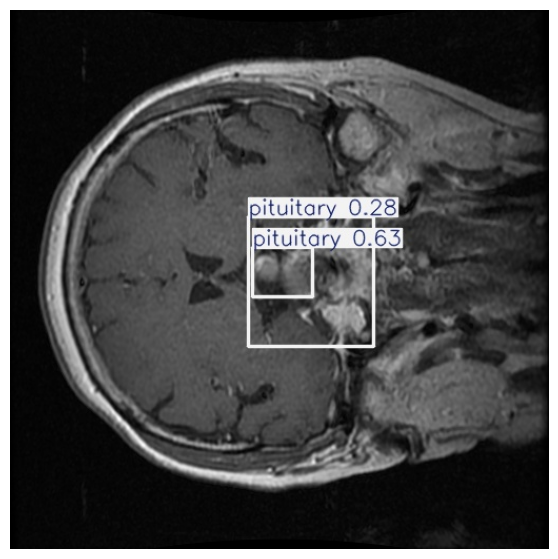

In [31]:
from PIL import Image
from matplotlib import pyplot as plt

img = Image.open("/content/runs/detect/predict/mri_57.jpg")

plt.figure(figsize=(7,7))
plt.imshow(img)
plt.axis("off")

(np.float64(-0.5), np.float64(2999.5), np.float64(2249.5), np.float64(-0.5))

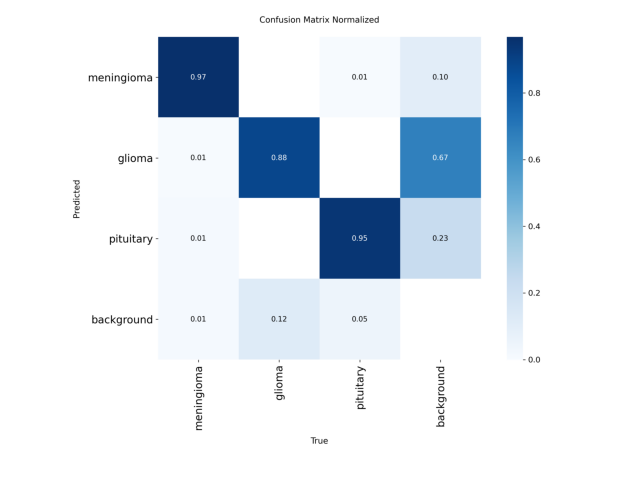

In [32]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/runs/detect/val-3/confusion_matrix_normalized.png")

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")